In [1]:
# import shutil

# source_dir = '../evaluation_setups/fig12_eyerissv2_pe_setup/workload/mobilenet0.5-sparse/uniform'
# destination_dir = '../evaluation_setups/Eyeriss_v2/workload_mobilenet'

# shutil.copytree(source_dir, destination_dir)

'../evaluation_setups/Eyeriss_v2/workload_mobilenet'

# MICRO 2022 Artifact Evaluation
# Sparseloop: An Analytical Approach To Sparse Tensor Accelerator Modeling
### Yannan N. Wu, Po-An Tsai, Angshuman Parashar, Vivienne Sze, Joel S. Emer

## Context

In this artifact, we provide evaluation setups for the important experiments (the motivating example, validations for accelerator designs, and the case study). Please follow the instructions in each cell to run the evaluations.

For each experiment, we give a *very conservative estimate* of how long the runs will take. The input specifications and related scripts can be found in `../evaluation_setups`. **The easiest way to validate the outputs is to compare the generated figure/table to the figure/table in the paper**, but we do provide a `ref_outputs` folder for each evaluation for more detailed comparison of results if necessary.



***Please note that to allow easier and faster reproduction, for most of the experiments, we directly provide the mappings found by our offline search*** *instead of letting Sparseloop performing online seach for the best mapping.* ***Sparseloop does allow automatic exploration of various mappings*** *as demonstrated in eval1 (more information on tool usage can be found [here](https://accelergy.mit.edu/tutorial.html) and [here](https://accelergy.mit.edu/sparse_tutorial.html)).*


### If you have any questions, please feel free to reach out at timeloop-accelergy@mit.edu. Thanks!




## Eval 1: Data representation format comparison (Fig.1 in paper)

This evaluation compares the processing speed and energy efficiency of two architectures that support different representation formats: 1) bitmask with gating; 2) coordinate list with skipping, running matrix multiplication workloads with various density degrees

### Step 1: Run sweep  ( <5min)

In [ ]:
%%bash
cd ../evaluation_setups/fig1_format_comparison_setup/scripts
echo "input specs at: ../evaluation_setups/fig1_format_comparison_setup/"
chmod +x sweep.sh
time ./sweep.sh

### Step 2: Parse and generate plot
1) run first cell to parse and plot

2) run next cell to display the generated figures

3) compare the figures to Fig.1 in paper

In [ ]:
%%bash
cd ../evaluation_setups/fig1_format_comparison_setup/scripts
time python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

cycles_fig = "../evaluation_setups/fig1_format_comparison_setup/outputs/fig_cycles.png"
energy_fig = "../evaluation_setups/fig1_format_comparison_setup/outputs/fig_energy_pJ.png"

display(Image(cycles_fig))
display(Image(energy_fig))

## Eval 2: EyerissV2 PE Validation ( 1. Fig.12 in paper; 2. showcase the main idea presented in Table 5)

We simulate mobilenet0.5 layers on a variation of eyeriss v2 PE with one compute unit.

We show experimental setups for both running evaluations with statistical density model (uniform density model) and actual data based density model. The modeling time is much longer with actual data based model. **This fact showcases the idea presented in Table 5: analytical modeling with statisical density model allows faster modeling.** (*Experiments for Table 5 requires manaul instrumantaion into the source code, which is not convienent for non-developers to setup, so we use this evlauation to showcase the main idea.*)

### Step 1: Run sweep with statistical density modeling (< 3min)

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
echo "input specs at: ../evaluation_setups/fig12_eyerissv2_pe_setup/"
time python3 sweep.py

### Step 2: Parse and generte plot

1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to per layer the ground truth and uniform modeling bars in Fig.12 in the paper

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig12_eyerissv2_pe_setup/outputs/uniform_only/fig.png"

display(Image(fig))

### Step 3: Run autal data evaluation on three layers ( <30 min)

Since actual data based evaluations are slow compared to statistical ones, the default evaluation only run on three layers. Please tune the `--max_layers` knob in the command below if you would like to try more layers.

**Note that this also demonstrate that our modeling speed with the statiscal density models are fast, which is the main idea presented in Table 5 in paper**

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
echo "input specs at: ../evaluation_setups/fig12_eyerissv2_pe_setup/"

# update the number of max layers below (<=8) to see more bar groups in fig12, but the run will take longer
time python3 sweep.py --include_actual --max_layers 3

### Step 4: Parse and generate plot


1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to the group of bars for **L07** in Fig.12 in the paper. 
   The main idea here is that compared to `baseline`, `acutal_data` based evlauation is able to accurately capture design behaviors with no error, whereas there is some error due statistical approximations when using the `uniform` distribution.

In [2]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
python3 parse_and_plot.py --include_actual

In [1]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig12_eyerissv2_pe_setup/outputs/uniform_actual/fig.png"

display(Image(fig))

## Eval 3: Eyeriss Validation (Table 7 in paper)

We simulate the AlexNet Conv layers on the Eyeriss accelerator, and present the DRAM traffic compression ratio. 


### Step 1: Run sweep (< 5min)

In [65]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
# cd ../evaluation_setups/table7_eyeriss_setup/scripts
# echo "input specs at: ../evaluation_setups/table7_eyeriss_setup/"
#time python3 sweep.py 
# To enable mapspace search, uncomment command below (note that the run will take much longer)
# mapspace search might end up with a slightly different mapping due to runtime randomness
time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.


Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 6468
  Factorization options along problem dimension M = 3003
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 5
  Factorization options along problem dimension N = 45
  Factorization options along problem dimension P = 5
  Factorization options along problem dimension Q = 6
Mapspace Dimension [IndexFactorization] Size: 131107977000
Mapspace Dimension [LoopPermutation] Size: 25401600
Mapspace Dimension [Spatial] Size: 64
Mapspace Dimension [DatatypeBypass] Size: 512
Mapspace split! Per-split Mapping Dimension [IndexFactorization] Size: 8194248563 Residue: 8
Mapspace construction complete.
Search configuration complete.


[  8] Utilization = 0.25 | pJ/Algorithmic-Compute =    1.117 | pJ/Compute =    4.858 | L6[WIO] Q13 S3 C4 - L5[] N2 C4 M2X C3X - L4[] C2 M8 P13 M8X - L3[I] N2 - L2[W] R3 - L1[O] Q1 - L0[] M2 C2 
[ 11] Utilization = 0.25 | pJ/Algorithmic-Compute =    1.172 | pJ/Compute =    5.094 | L6[WIO] Q13 S3 C4 - L5[] N2 C4 M2X C3X - L4[] C4 M8 P13 M8X - L3[I] N2 - L2[W] R3 - L1[O] Q1 - L0[] M2 
[ 15] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.394 | pJ/Compute =    6.062 | L6[WIO] S3 Q13 C4 - L5[] N2 C4 M2X C4X - L4[] C3 P13 M8 M8X - L3[I] N2 - L2[W] R3 - L1[O] Q1 - L0[] M2 
[  1] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.172 | pJ/Compute =    5.095 | L6[WIO] C4 Q13 S3 - L5[] N2 C4 M2X C2X - L4[] C6 M8 P13 M8X - L3[I] N2 - L2[W] R3 - L1[O] Q1 - L0[] M2 
[  9] Utilization = 0.25 | pJ/Algorithmic-Compute =    1.117 | pJ/Compute =    4.858 | L6[WIO] Q13 S3 C4 - L5[] N2 C4 M2X C3X - L4[] C2 M8 P13 M8X - L3[I] N2 - L2[W] R3 C2 - L1[O] Q1 - L0[] M2 
[ 14] Utilization = 0.02 | pJ/Algorithm

[ 12] Utilization = 0.27 | pJ/Algorithmic-Compute =    1.596 | pJ/Compute =    6.937 | L6[WIO] S3 C3 M4 P13 - L5[] N4 M2 C2 Q13X - L4[] C4 M4 C4X - L3[I] Q1 - L2[W] R3 - L1[O] M4 - L0[] M2 C2 
[  2] Utilization = 0.54 | pJ/Algorithmic-Compute =    1.595 | pJ/Compute =    6.934 | L6[WIO] P13 M4 C3 S3 - L5[] N4 M2 C2 Q13X - L4[] C2 M4 C8X - L3[I] Q1 - L2[W] R3 - L1[O] M4 - L0[] M2 C2 
[ 12] Utilization = 0.27 | pJ/Algorithmic-Compute =    1.567 | pJ/Compute =    6.813 | L6[WIO] S3 M4 P13 C3 - L5[] N4 M2 C2 Q13X - L4[] M4 C4 C4X - L3[I] Q1 - L2[W] R3 - L1[O] M4 - L0[] M2 C2 
[  3] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.150 | pJ/Compute =    4.998 | L6[WIO] C6 M2 S3 - L5[] Q13 C32 M4X - L4[] N2 P13 M8X - L3[I] Q1 - L2[W] R3 - L1[O] M2 - L0[] N2 M2 
[  2] Utilization = 0.54 | pJ/Algorithmic-Compute =    1.580 | pJ/Compute =    6.869 | L6[WIO] M4 S3 C3 P13 - L5[] N4 M2 C2 Q13X - L4[] M4 C2 C8X - L3[I] Q1 - L2[W] R3 - L1[O] M4 - L0[] M2 C2 
[ 10] Utilization = 0.17 | pJ/Algorithmi

[ 10] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.045 | pJ/Compute =    4.544 | L6[WIO] N2 - L5[] M16 C4 C8X - L4[] C3 Q13 P13 N2X S3X M2X - L3[I] Q1 - L2[W] R3 C2 - L1[O] M2 - L0[I] M4 
[  4] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[ 10] STATEMENT: 3000 invalid mappings (2988 fanout, 12 capacity) found since the last valid mapping, terminating search.
[ 12] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.487 | pJ/Compute =    9.042 | L5[WIO] N2 M3 C32 - L4[IO] M4 N2 P13 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] Q1 - L1[W] R3 C4 - L0[O] M16 
[ 15] STATEMENT: 3000 invalid mappings (2987 fanout, 13 capacity) found since the last valid mapping, terminating search.
[ 12] STATEMENT: 3000 invalid mappings (2988 fanout, 12 capacity) found since the last valid mapping, terminating search.
[  7] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.070 | pJ/Compute =    4.651 | L6[WIO] N2 - L5[] M16 C4 C8X - L4[] C2 P13 

...

[  1] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.960 | pJ/Compute =    3.267 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X - L4[] M2 P7 Q28 S5 M4X C3X - L3[I] Q1 - L2[W] R5 - L1[O] M2 - L0[] M2 C2 
[  3] Utilization = 0.25 | pJ/Algorithmic-Compute =    1.679 | pJ/Compute =    2.798 | L6[WIO] M2 P7 - L5[] Q7 N4 M4 P2X M2X - L4[] C8 P2 S5 Q2X C6X - L3[I] Q1 - L2[W] R5 - L1[O] Q1 - L0[] Q2 M16 
[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.958 | pJ/Compute =    3.264 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X - L4[] M2 P7 Q28 S5 M4X C2X - L3[I] Q1 - L2[W] R5 C3 - L1[O] M2 - L0[] M2 
[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.951 | pJ/Compute =    3.251 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X - L4[] M2 P7 Q28 S5 M4X C2X - L3[I] Q1 - L2[W] R5 C3 - L1[O] M2 - L0[I] M2 
[  9] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.552 | pJ/Compute =    2.586 | L6[WIO] M2 P2 - L5[] N4 C8 P2X M4X - L4[] S5 Q28 M2 C3 P7 M4X C2X - L3[I] Q1 - L2[W] R5 - L1[O] M2 - L0[] M2 
[  9] Utilizat

[ 11] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.475 | pJ/Compute =    2.458 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X C2X - L4[] S5 P7 M2 Q28 M4X - L3[I] Q1 - L2[W] R5 - L1[O] M2 - L0[] M2 C3 
[  7] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.486 | pJ/Compute =    2.476 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X - L4[] P7 C3 S5 M2 Q28 M4X - L3[I] Q1 - L2[W] R5 - L1[O] M2 - L0[] M2 C2 
[  8] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.486 | pJ/Compute =    2.476 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X - L4[] P7 C3 S5 M2 Q28 M4X - L3[I] Q1 - L2[W] R5 C2 - L1[O] M2 - L0[] M2 
[  8] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.478 | pJ/Compute =    2.464 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X - L4[] P7 C3 S5 M2 Q28 M4X - L3[I] Q1 - L2[W] R5 C2 - L1[O] M2 - L0[I] M2 
[  1] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.447 | pJ/Compute =    2.412 | L6[WIO] P2 M2 - L5[] N4 C8 P2X M4X - L4[] S5 M2 Q28 P7 M4X C3X - L3[I] Q1 - L2[W] R5 - L1[O] M2 - L0[] M2 C2 
[  4] Utilization

[  6] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.876 | pJ/Compute =    3.126 | L6[WIO] P7 S5 C3 - L5[] Q2 C4 Q2X M4X C2X - L4[] M32 C2 N2 Q7 P4X M2X - L3[I] Q1 - L2[W] R5 N2 - L1[O] Q1 - L0[] Q1 
[  5] STATEMENT: 3000 invalid mappings (2991 fanout, 9 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid mappings (2986 fanout, 14 capacity) found since the last valid mapping, terminating search.
[ 11] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.704 | pJ/Compute =    2.839 | L6[WIO] S5 M4 P2 C3 N4 - L5[] Q7 C2 Q4X M2X C2X - L4[] P7 C2 M4X C2X - L3[I] Q1 - L2[W] R5 - L1[O] M4 - L0[] P2 M2 
[ 13] STATEMENT: 3000 invalid mappings (2990 fanout, 10 capacity) found since the last valid mapping, terminating search.
[ 11] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.508 | pJ/Compute =    2.513 | L6[WIO] M4 S5 C3 N4 P2 - L5[] Q7 C2 Q4X M2X C2X - L4[] C2 P7 M4X C2X - L3[I] Q1 - L2[W] R5 - L1[O] M4 - L0[] P2 M2 
[  1] STATEMENT: 3000 inv



Summary stats for best mapping found by mapper:
  Utilization = 1.00 | pJ/Algorithmic-Compute =    1.463 | pJ/Compute =    2.438
Running job:  alexnet_conv5
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output
	Running test:  alexnet_conv5
Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv1/output
	Running test:  alexnet_conv1
Running job:  alexnet_conv4
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv4/output
	Running test:  alexnet_conv4
Running job:  alexnet_conv3
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv3/output
	Running test:  alexnet_conv3
Running job:  alexnet_conv2
Found and overwrite existing resu


real	8m53.730s
user	50m41.359s
sys	0m1.553s


In [11]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.


Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 7
  Factorization options along problem dimension M = 3234
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 5
  Factorization options along problem dimension N = 45
  Factorization options along problem dimension P = 175
  Factorization options along problem dimension Q = 336
Mapspace Dimension [IndexFactorization] Size: 299500740000
Mapspace Dimension [LoopPermutation] Size: 25401600
Mapspace Dimension [Spatial] Size: 64
Mapspace Dimension [DatatypeBypass] Size: 512
Mapspace split! Per-split Mapping Dimension [IndexFactorization] Size: 18718796250 Residue: 0
Mapspace construction complete.
Search configuration complete.


[ 11] Utilization = 0.44 | pJ/Algorithmic-Compute =    2.126 | pJ/Compute =    2.126 | L6[WIO] N2 M4 - L5[] Q8 M3 N2X M2X C3X - L4[] S11 P28 M2 Q7X - L3[I] Q1 - L2[W] R11 - L1[O] Q1 - L0[] P2 M2 
[ 13] Utilization = 0.15 | pJ/Algorithmic-Compute =    2.128 | pJ/Compute =    2.128 | L6[WIO] N2 C3 M4 - L5[] Q8 M3 N2X M2X - L4[] S11 P28 M2 Q7X - L3[I] Q1 - L2[W] R11 - L1[O] Q1 - L0[] P2 M2 
[ 12] Utilization = 0.15 | pJ/Algorithmic-Compute =    2.128 | pJ/Compute =    2.128 | L6[WIO] M4 N2 - L5[] Q8 M3 C3 N2X M2X - L4[] P28 S11 M2 Q7X - L3[I] Q1 - L2[W] R11 - L1[O] Q1 - L0[] P2 M2 
[ 10] Utilization = 0.15 | pJ/Algorithmic-Compute =    2.122 | pJ/Compute =    2.122 | L6[WIO] N2 M4 - L5[] Q8 M3 N2X M2X - L4[] M2 P28 C3 S11 Q7X - L3[I] Q1 - L2[W] R11 - L1[O] Q1 - L0[] P2 M2 
[ 15] STATEMENT: 3000 invalid mappings (2989 fanout, 11 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid mappings (2988 fanout, 12 capacity) found since the last valid mapp



Summary stats for best mapping found by mapper:
  Utilization = 0.44 | pJ/Algorithmic-Compute =    1.878 | pJ/Compute =    1.878
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.


Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 1470
  Factorization options along problem dimension M = 3003
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 5
  Factorization options along problem dimension N = 45
  Factorization options along problem dimension P = 75
  Factorization options along problem dimension Q = 126
Mapspace Dimension [IndexFactorization] Size: 9386139262500
Mapspace Dimension [LoopPermutation] Size: 25401600
Mapspace Dimension [Spatial] Size: 64
Mapspace Dimension [DatatypeBypass] Size: 512
Mapspace split! Per-split Mapping Dimension [IndexFactorization] Size: 586633703907 Residue: 12
Mapspace construction complete.
Search configuration complete.


...

[  2] Utilization = 0.09 | pJ/Algorithmic-Compute =   11.508 | pJ/Compute =   41.846 | L5[WIO] N2 M6 C32 - L4[IO] M16 P13 C4 Q13X - L3[] Q1 S3Y - L2[I] N2 - L1[W] R3 C2 - L0[O] M4 
[  1] Utilization = 0.09 | pJ/Algorithmic-Compute =   10.949 | pJ/Compute =   39.816 | L5[WIO] N2 M6 C32 - L4[IO] M16 P13 C2 Q13X - L3[] Q1 C4Y S3Y - L2[I] N2 - L1[W] R3 - L0[O] M4 
[  0] Utilization = 0.09 | pJ/Algorithmic-Compute =   10.908 | pJ/Compute =   39.665 | L5[WIO] N2 M6 C32 - L4[IO] M16 P13 C2 Q13X - L3[] Q1 C2Y S3Y - L2[I] N2 - L1[W] R3 C2 - L0[O] M4 
[  0] Utilization = 0.16 | pJ/Algorithmic-Compute =    7.391 | pJ/Compute =   26.878 | L5[WIO] Q13 M24 C128 - L4[IO] P13 M8X - L3[] Q1 C2Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] N4 M2 
[  8] Utilization = 0.21 | pJ/Algorithmic-Compute =   67.909 | pJ/Compute =  246.941 | L5[WIO] Q13 M4 - L4[IO] M12 N2 P13 C32 M8X - L3[] Q1 C4Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] N2 
[  4] Utilization = 0.07 | pJ/Algorithmic-Compute =   12.749 | pJ/Compute =   46.359 | 


Summary stats for best mapping found by mapper:
  Utilization = 0.83 | pJ/Algorithmic-Compute =    3.242 | pJ/Compute =    5.404


[ 12] Utilization = 0.38 | pJ/Algorithmic-Compute =   13.648 | pJ/Compute =   49.628 | L5[WIO] N2 M8 C16 - L4[IO] M3 N2 P13 C16 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] M4 
[  2] Utilization = 0.24 | pJ/Algorithmic-Compute =   68.337 | pJ/Compute =  248.497 | L5[WIO] Q13 N2 M4 C64 - L4[IO] M4 P13 C2 M12X - L3[] Q1 M2Y S3Y - L2[I] N2 - L1[W] R3 C2 - L0[O] Q1 
[  1] Utilization = 0.21 | pJ/Algorithmic-Compute =    9.546 | pJ/Compute =   34.714 | L5[WIO] Q13 N2 M4 C256 - L4[IO] M4 P13 M8X - L3[] Q1 M3Y S3Y - L2[I] N2 - L1[W] R3 - L0[O] Q1 
[  9] Utilization = 0.17 | pJ/Algorithmic-Compute =    5.268 | pJ/Compute =   19.157 | L5[WIO] M48 C128 - L4[IO] M2 P13 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] N2 - L1[W] R3 - L0[O] N2 M2 
[ 10] Utilization = 0.08 | pJ/Algorithmic-Compute =  131.914 | pJ/Compute =  479.688 | L5[WIO] Q13 N2 M2 C2 - L4[IO] M16 N2 P13 C32 M2X - L3[] Q1 M2Y C2Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] M3 
[  7] Utilization = 0.38 | pJ/Algorithmic-Compute =   13.648 | pJ/

[ 10] Utilization = 0.47 | pJ/Algorithmic-Compute =  131.046 | pJ/Compute =  476.531 | L5[WIO] Q13 N4 M2 - L4[IO] M4 P13 C64 M12X - L3[] Q1 C4Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] M4 
[  5] Utilization = 0.51 | pJ/Algorithmic-Compute =   13.036 | pJ/Compute =   47.404 | L5[WIO] N2 M4 C32 - L4[IO] N2 P13 C8 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] M24 
[  8] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.813 | pJ/Compute =   10.229 | L5[WIO] N2 M4 C64 - L4[IO] M3 N2 P13 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 C4 - L0[O] M8 
[ 13] Utilization = 0.45 | pJ/Algorithmic-Compute =   13.619 | pJ/Compute =   49.524 | L5[WIO] N2 M4 C64 - L4[IO] M3 N2 P13 C4 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] M8 
[  3] Utilization = 0.51 | pJ/Algorithmic-Compute =   13.036 | pJ/Compute =   47.404 | L5[WIO] N2 M4 C32 - L4[IO] N2 P13 C4 Q13X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] M24 
[  4] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.451 | pJ/Compute =    8.91

[  3] Utilization = 0.51 | pJ/Algorithmic-Compute =    3.056 | pJ/Compute =   11.111 | L5[WIO] N4 M2 C32 - L4[IO] M12 P13 Q13X - L3[] Q1 C4Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] M16 
[ 13] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.885 | pJ/Compute =   10.490 | L5[WIO] N4 M2 C16 - L4[IO] M12 P13 Q13X - L3[] Q1 C4Y S3Y - L2[I] Q1 - L1[W] R3 C4 - L0[O] M16 
[ 15] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.880 | pJ/Compute =   10.472 | L5[WIO] N2 M4 C64 - L4[IO] M4 P13 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] Q1 - L1[W] R3 C2 - L0[O] N2 M12 
[ 12] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.487 | pJ/Compute =    9.042 | L5[WIO] N2 M3 C32 - L4[IO] M4 N2 P13 Q13X - L3[] Q1 M2Y C2Y S3Y - L2[I] Q1 - L1[W] R3 C4 - L0[O] M16 
[ 11] Utilization = 0.51 | pJ/Algorithmic-Compute =    3.004 | pJ/Compute =   10.922 | L5[WIO] N2 M8 C64 - L4[IO] M2 N2 P13 Q13X - L3[] Q1 C4Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] M24 
[ 13] Utilization = 0.51 | pJ/Algorithmic-Compute =    2.754 | pJ/Compute 

In [6]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --workload_path workload_mobilenet

  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/constructor.py", line 41, in get_single_data
    node = self.get_single_node()
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/composer.py", line 36, in get_single_node
    document = self.compose_document()
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/composer.py", line 55, in compose_document
    node = self.compose_node(None, None)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/composer.py", line 84, in compose_node
    node = self.compose_mapping_node(anchor)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/composer.py", line 133, in compose_mapping_node
    item_value = self.compose_node(node, item_key)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/composer.py", line 84, in compose_node
    node = self.compose_mapping_node(anchor)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/composer.py", line 133, in compose_mapping_node
    ite

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.


Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 924
  Factorization options along problem dimension M = 924
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 1
  Factorization options along problem dimension N = 1
  Factorization options along problem dimension P = 126
  Factorization options along problem dimension Q = 252
  Factorization options along problem dimension G = 1
Mapspace Dimension [IndexFactorization] Size: 27109095552
Mapspace Dimension [LoopPermutation] Size: 1625702400
Mapspace Dimension [Spatial] Size: 81
Mapspace Dimension [DatatypeBypass] Size: 512
Mapspace split! Per-split Mapping Dimension [IndexFactorization] Size: 1694318472 Residue: 0
Mapspace construction complete.
Search configuration complete.


[  0] Utilization = 0.08 | pJ/Algorithmic-Compute =    2.073 | pJ/Compute =    2.840 | L6[WIO] P4 M2 Q4 - L5[] G1 Q2X - L4[] P4 Q2 M2 C64 Q2X P2X M2X - L3[I] G1 - L2[W] G1 - L1[O] M4 - L0[] M2 
[  5] Utilization = 0.08 | pJ/Algorithmic-Compute =    2.394 | pJ/Compute =    3.280 | L6[WIO] Q4 C2 M4 P8 - L5[] M4 C8 Q2X - L4[] Q2 P4 M4 Q2X C4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[  0] Utilization = 0.08 | pJ/Algorithmic-Compute =    2.040 | pJ/Compute =    2.795 | L6[WIO] P4 M2 Q4 - L5[] G1 Q2X - L4[] P4 Q2 M2 C64 Q2X P2X M2X - L3[I] G1 - L2[W] G1 - L1[O] M4 - L0[I] M2 
[  3] Utilization = 0.04 | pJ/Algorithmic-Compute =    2.242 | pJ/Compute =    3.071 | L6[WIO] C2 M4 Q4 P8 - L5[] M4 C8 Q2X - L4[] P4 Q2 M4 Q2X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] C2 
[ 12] Utilization = 0.08 | pJ/Algorithmic-Compute =    2.394 | pJ/Compute =    3.280 | L6[WIO] Q4 C2 M4 P8 - L5[] M4 C8 Q2X C2X - L4[] Q2 P4 M4 Q2X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[  5] Utilization = 0.08 | pJ/A

[ 15] Utilization = 0.02 | pJ/Algorithmic-Compute =    1.890 | pJ/Compute =    2.589 | L6[WIO] Q4 C32 P8 M4 - L5[] M4 Q2X - L4[] M4 Q2 P4 Q2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] C2 
[ 14] Utilization = 0.08 | pJ/Algorithmic-Compute =    2.137 | pJ/Compute =    2.927 | L6[WIO] P8 C2 Q4 M4 - L5[] M4 C8 Q2X C4X - L4[] P4 M4 Q2 Q2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[W] G1 
[  3] Utilization = 0.04 | pJ/Algorithmic-Compute =    1.950 | pJ/Compute =    2.671 | L6[WIO] M4 Q4 C2 P8 - L5[] M4 C8 Q2X - L4[] Q2 M4 P4 Q2X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] C2 
[ 15] Utilization = 0.02 | pJ/Algorithmic-Compute =    1.744 | pJ/Compute =    2.389 | L6[WIO] Q4 C32 P8 M4 - L5[] M4 Q2X - L4[] M4 Q2 P4 Q2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[O] C2 
[  4] Utilization = 0.04 | pJ/Algorithmic-Compute =    1.738 | pJ/Compute =    2.380 | L6[WIO] C2 P8 Q4 M4 - L5[] M4 C8 Q2X - L4[] M4 P4 Q2 Q2X C2X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[O] G1 
[  3] Utilization = 0.04 | pJ/Algorithmic-Compute

...

[  6] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.597 | pJ/Compute =    2.754 | L6[WIO] C8 M4 - L5[] G1 P2X C8X - L4[] M4 Q4 M2X C4X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[] P2 M16 
[  4] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.534 | pJ/Compute =    2.644 | L6[WIO] G1 - L5[] C32 P2X M4X C2X - L4[] M2 Q4 P2 M4X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M16 C4 
[  2] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.719 | pJ/Compute =    2.964 | L6[WIO] P2 M8 - L5[] M8 C2 M4X C4X - L4[] Q2 C4 P2 C8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 C2 
[  5] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.534 | pJ/Compute =    2.644 | L6[WIO] G1 - L5[] C32 P2X M4X C2X - L4[] M2 Q4 P2 M4X C2X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[] M16 C2 
[  2] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.654 | pJ/Compute =    2.852 | L6[WIO] M8 P2 - L5[] M8 C2 M4X C4X - L4[] C4 Q2 P2 C8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 C2 
[  7] STATEMENT: 2000 suboptimal mappings found 

/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv1.yaml
0.73
Running job:  mobilenet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv1/output
	Running test:  mobilenet_conv1
mobilenet_conv1  reaches timeout limit
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv2.yaml
0.86
Running job:  mobilenet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv2/output
	Running test:  mobilenet_conv2
mobilenet_conv2  reaches timeout limit
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv3.yaml
0.83
Running job:  mobilenet_conv3
	Running test:  mobilenet_conv3
mobilenet_conv3  reaches timeout limit
/home/workspace/2022.micro.artifact/evalua

Interrupt caught. Mapper threads will terminate after completing any ongoing evaluations.
[  1] STATEMENT: global termination flag activated, terminating search.
[ 13] STATEMENT: global termination flag activated, terminating search.
[  9] STATEMENT: global termination flag activated, terminating search.
[  4] STATEMENT: global termination flag activated, terminating search.
[  0] STATEMENT: global termination flag activated, terminating search.
[ 15] STATEMENT: global termination flag activated, terminating search.
[  5] STATEMENT: global termination flag activated, terminating search.
[ 10] STATEMENT: global termination flag activated, terminating search.
[ 11] STATEMENT: global termination flag activated, terminating search.
[  6] STATEMENT: global termination flag activated, terminating search.
[ 12] STATEMENT: global termination flag activated, terminating search.
[ 14] STATEMENT: global termination flag activated, terminating search.
[  2] STATEMENT: global termination flag activ


real	40m1.268s
user	357m2.466s
sys	0m37.534s



Summary stats for best mapping found by mapper:
  Utilization = 0.67 | pJ/Algorithmic-Compute =    1.391 | pJ/Compute =    2.399


### Step 2: Parse and generate table

1) run the first cell to parse results and print table entries

2) compare the entries to the second row in table 7 in the paper

***Please note that we used the public 45nm data for energy modeling in this evaluation instead of the 65nm private PDK used in our paper's evaluations.*** *Although the the DRAM compression ratio is not impacted, the energy reported in the raw results can be different. However, we do see significant energy reduction with the gating SAF implemented in this architecture.*

In [15]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper

Bad value in file PosixPath('/usr/local/bin/conda/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle'), line 153 ('mathtext.rm  : serif'): 'ParseResults' object has no attribute 'isinstance'


Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output/total_energy_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv5/output/total_memory_plot.png


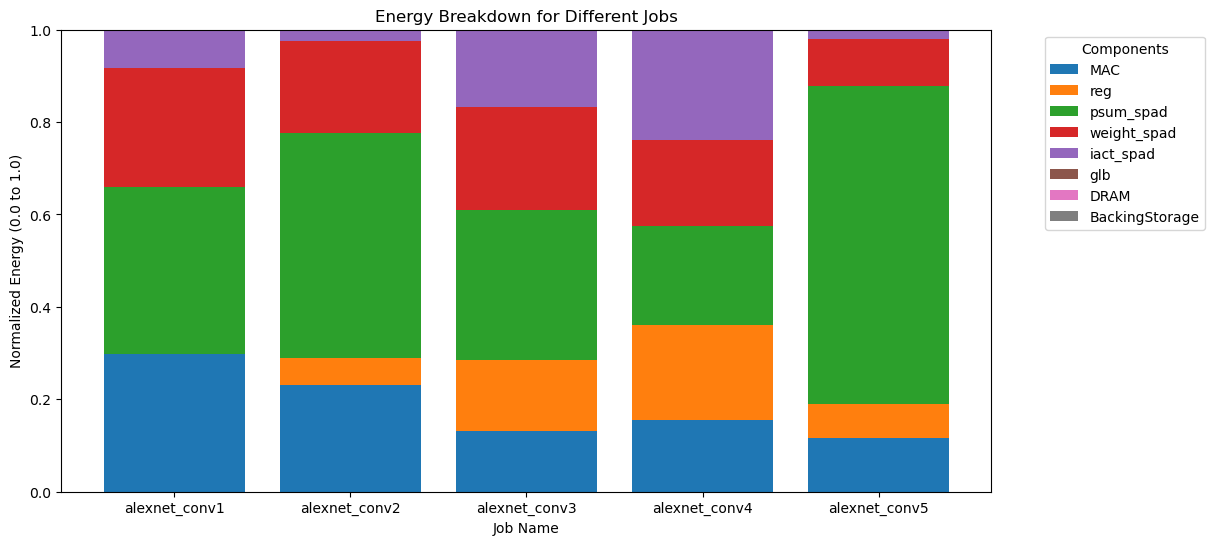

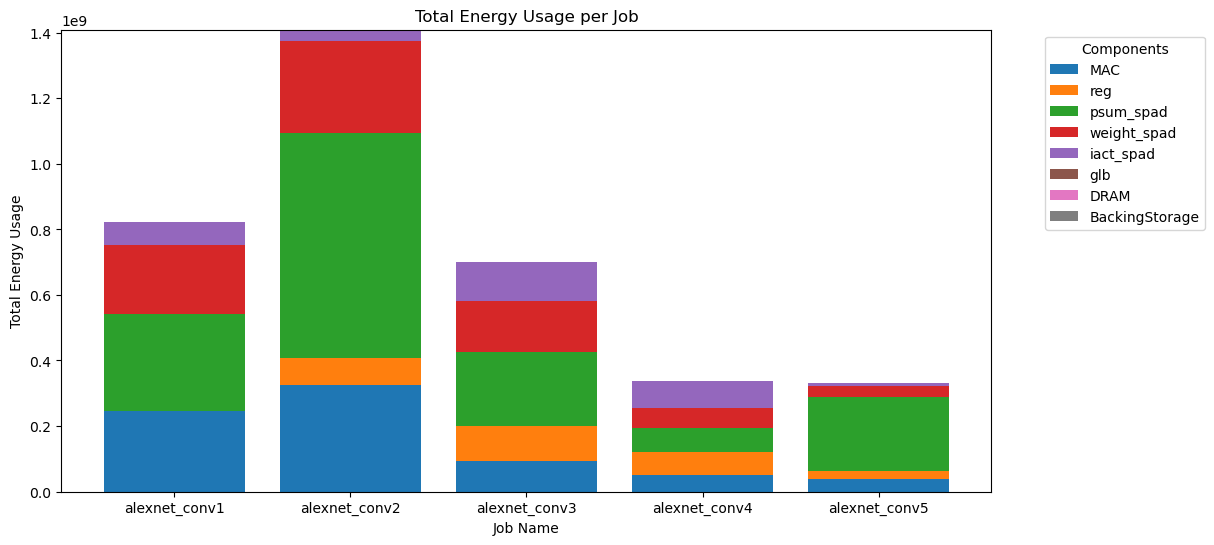

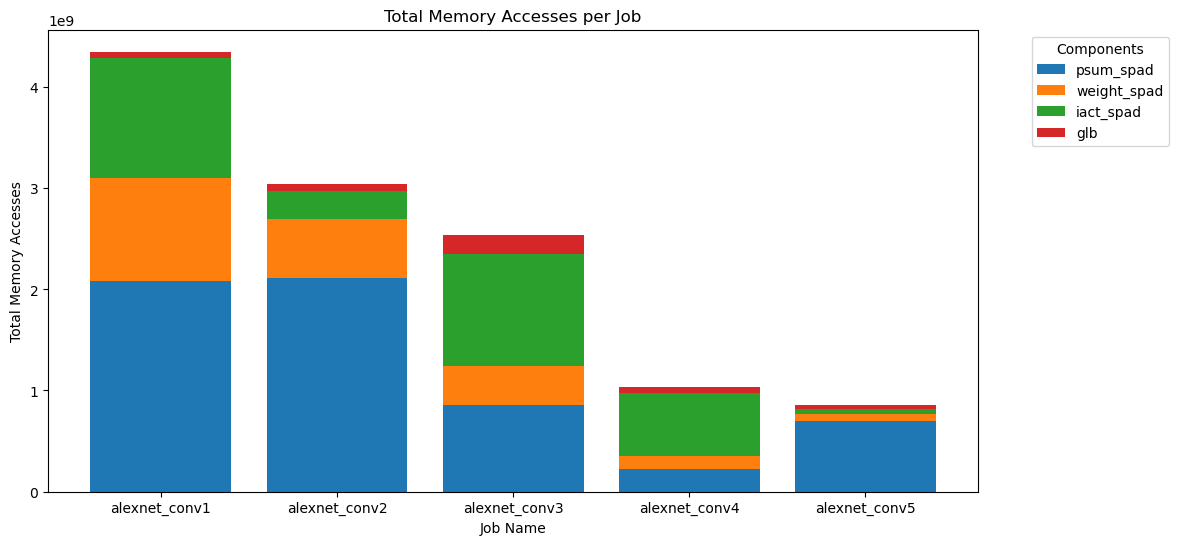

In [16]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/energy_breakdown_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_memory_plot.png"))

In [7]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --workload_path workload_mobilenet

/usr/local/bin/conda/lib/python3.8/site-packages/matplotlib/transforms.py:1140: RuntimeWarning: WRITEBACKIFCOPY detected in array_dealloc.  Required call to PyArray_ResolveWritebackIfCopy or PyArray_DiscardWritebackIfCopy is missing.
  ys = min(points[:, 1]), max(points[:, 1])


Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8/output/total_energy_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8/output/total_memory_plot.png


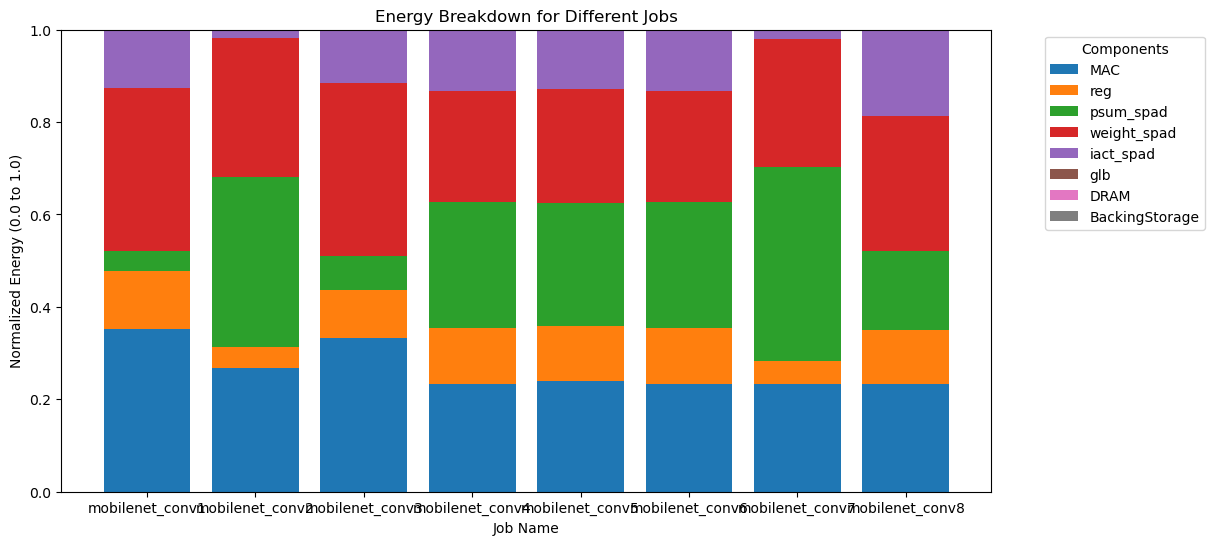

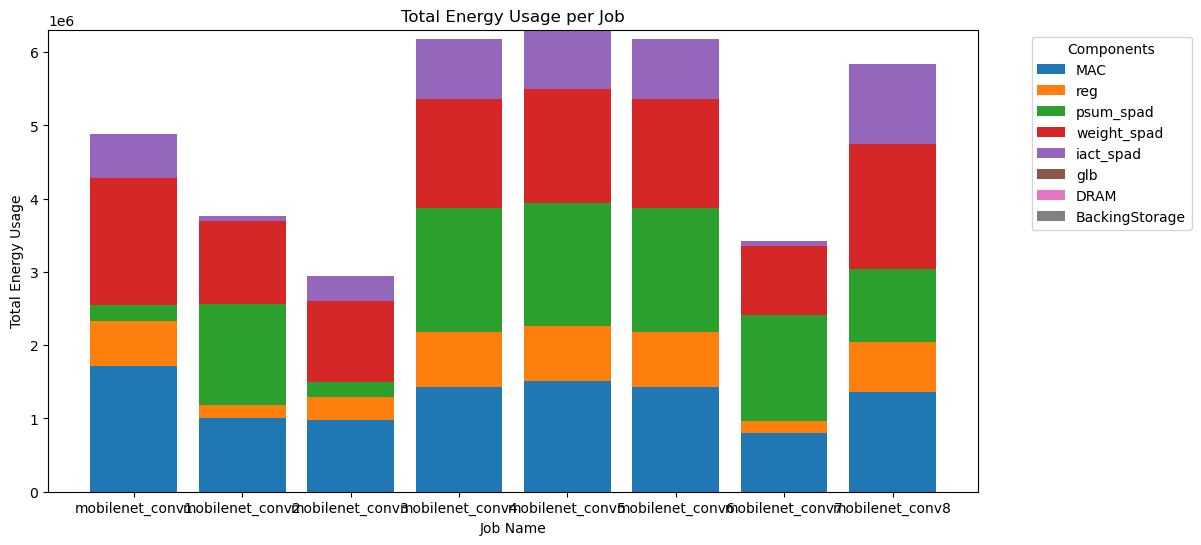

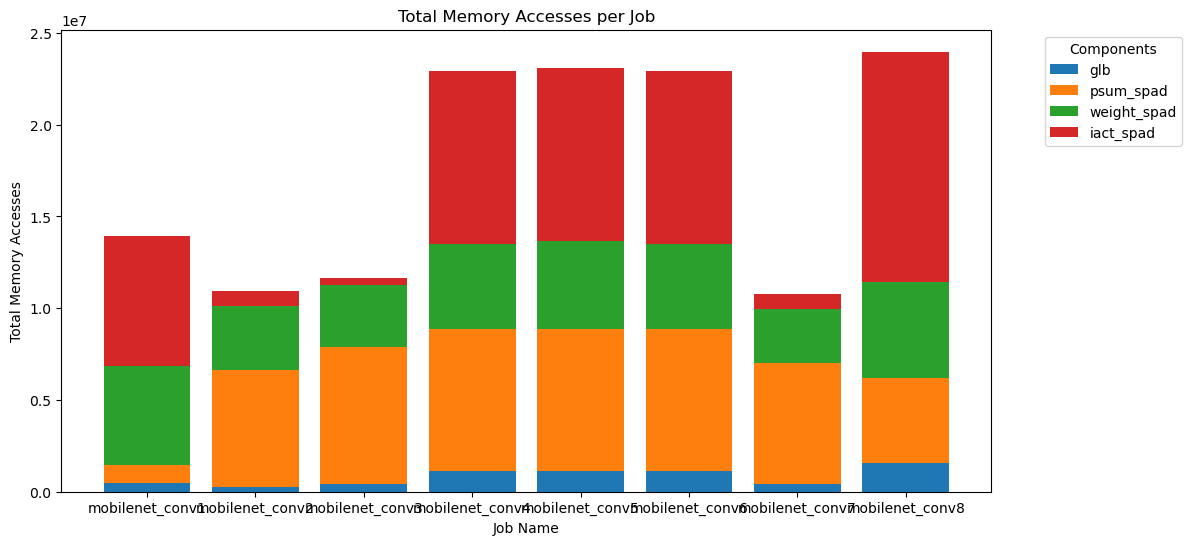

In [8]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs/mobilenet_conv8/output/energy_breakdown_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/mobilenet_conv8/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/mobilenet_conv8/output/total_memory_plot.png"))

## Eval 4: Dual Side Sparse Tensor Core Validation (Fig.13 in paper)

We simulate matrix multiplication workloads with various sparsity degrees running on dual side sparse tensor core design.

### Step 1: Run sweep ( < 5min)

In [ ]:
%%bash
cd ../evaluation_setups/fig13_dstc_setup/scripts
echo "input specs at: ../evaluation_setups/fig13_dstc_setup/"
time python3 sweep.py

### Step 2: Parse and generate plot

1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to Fig.13 in the paper

In [ ]:
%%bash
cd ../evaluation_setups/fig13_dstc_setup/scripts
python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig13_dstc_setup/outputs/fig.png"

display(Image(fig))

## Eval 5: Sparse tensor core validation and the related case study (Figure 15 in paper)

We simulate the selected ResNet50 layers on the sparse tensor core (STC) accelerator and compare various sparse designs based on the tensor core setup. 

Please see more details on the various designs validated/explored in Section 6.3.5 and Section 6.4 in the paper. 


### Step 1: Run sweep ( < 8min)

In [4]:
%%bash
cd ../evaluation_setups/fig15_stc_related_setup/scripts
echo "input specs at: ../evaluation_setups/fig15_stc_related_setup/"
time python3 sweep.py
# To enable mapspace search, uncomment command below (note that the run will take much longer)
# mapspace search might end up with a slightly different mapping due to runtime randomness
# time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/fig15_stc_related_setup/
Utilization = 1.00 | pJ/Compute =    1.832
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.643 | pJ/Compute =    1.643
Utilization = 0.83 | pJ/Algorithmic-Compute =    2.415 | pJ/Compute =    5.489
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.643 | pJ/Compute =    1.643
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.643 | pJ/Compute =    1.643
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.311 | pJ/Compute =    1.311
Utilization = 1.00 | pJ/Compute =    1.845
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.682 | pJ/Compute =    1.682
Utilization = 0.72 | pJ/Algorithmic-Compute =    1.502 | pJ/Compute =    5.564
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.682 | pJ/Compute =    1.682
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.682 | pJ/Compute =    1.682
Utilization = 1.00 | pJ/Algorithmic-Compute =    1.271 | pJ/Compute =    1.271
Utilization = 1.00 | pJ/Compute =    1.781
Utilization = 1.00 


real	1m30.611s
user	0m30.826s
sys	0m1.369s


### Step2: Parse and generate plot

1) run first cell to parse and generate figures

2) run second cell to display the figures

3) compare the generated figure to Fig.15 in the paper

  ***Please note that we used the public 45nm data for energy modeling in this evaluation instead of the 65nm private PDK used in our paper's evaluations.*** As a result, the normalized cycles will match the figure presented in paper, but **the normalized energy will not be an exact match. However, the trends do stay the same for both technology nodes.**


In [5]:
%%bash
cd ../evaluation_setups/fig15_stc_related_setup/scripts
python3 parse_and_plot.py --raw ../outputs/resnet50_selected/*

# If used mapspace search in the previous step
# python3 parse_and_plot.py --raw ../outputs/resnet50_selected/* --stats_prefix timeloop-mapper

dummping stats to  ../csv_results/resnet50_selected-normed-WD-1.0-TC-RF2x-24-bandwidth.csv
Fig saved to  /home/nelliewu/research/workspace/sparse-modeling/micro22-sparseloop-artifact/workspace/2022.micro.artifact/evaluation_setups/fig15_stc_related_setup/outputs/fig_cycles.png
Fig saved to  /home/nelliewu/research/workspace/sparse-modeling/micro22-sparseloop-artifact/workspace/2022.micro.artifact/evaluation_setups/fig15_stc_related_setup/outputs/fig_energy.png


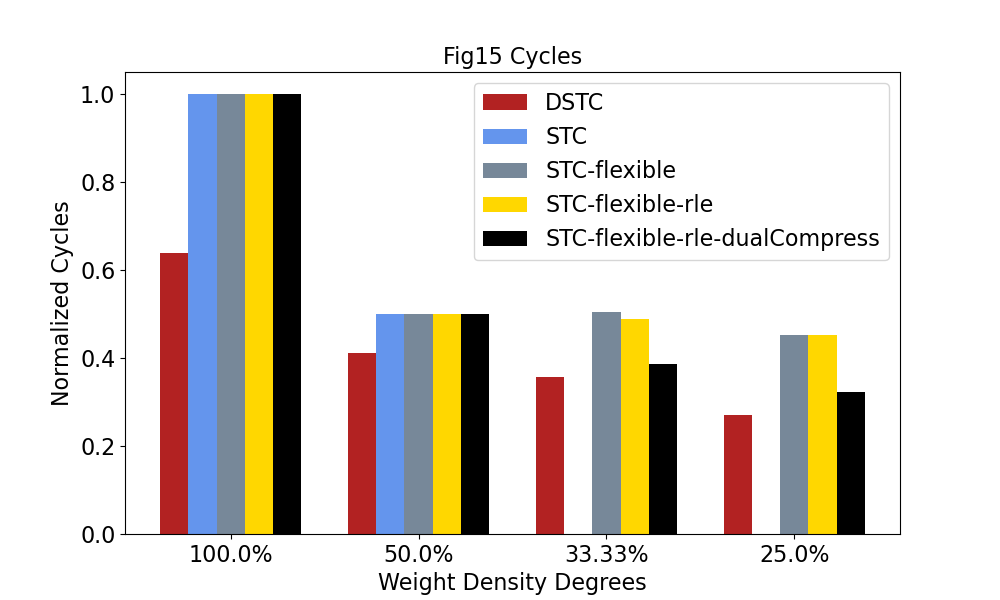

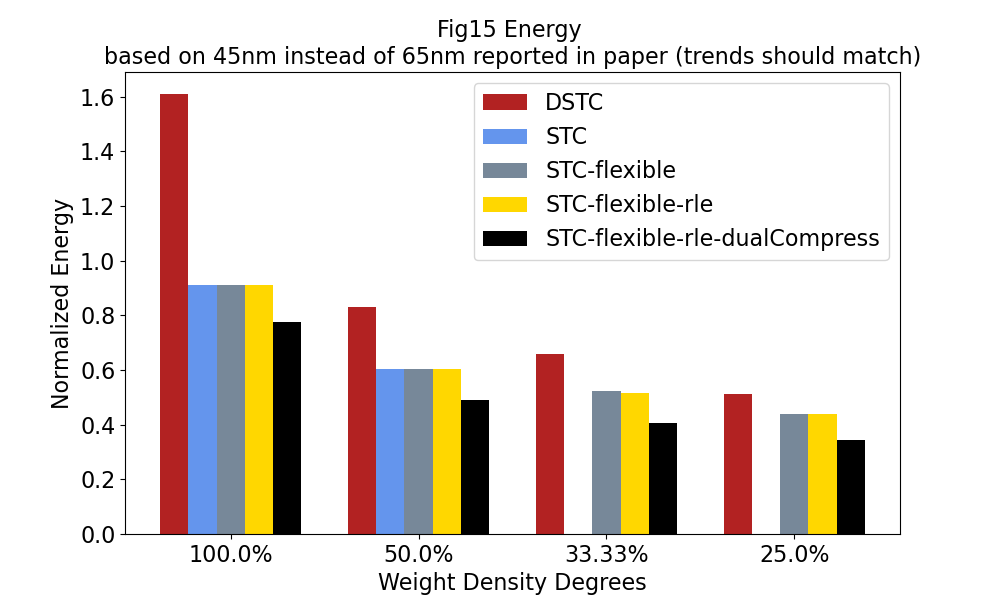

In [6]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

cycles_fig = "../evaluation_setups/fig15_stc_related_setup/outputs/fig_cycles.png"
energy_fig = "../evaluation_setups/fig15_stc_related_setup/outputs/fig_energy.png"

display(Image(cycles_fig))
display(Image(energy_fig))